# Clinical Early Warning System — Patient Survival Prediction
**Dataset:** Kaggle Patient Survival Prediction (train.csv)
**Target:** `hospital_death` — predict if a patient will die during hospitalization

## Notebook Structure
- **Part 0** — Dataset Overview
- **Part 1** — Feature Selection (Missing %, RF Importance, Correlation)
- **Part 2** — Gen 1: DNN with SGD vs Adam
- **Part 3** — Gen 2: LSTM / Bidirectional LSTM / GRU
- **Part 4** — Gen 3: ClinicalBERT (Frozen vs Fine-Tune)
- **Part 5** — Final Comparison Table

---
# PART 0 — Dataset Overview

In [11]:
# ============================================================
# STEP 0: IMPORT LIBRARIES
# WHY: pandas/numpy for data handling, matplotlib/seaborn for
#      visualization, sklearn for ML utilities
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded')

Libraries loaded


In [12]:
# ============================================================
# STEP 1: LOAD DATASET
# WHY: Load the raw train.csv and understand its shape
#      before any cleaning or selection
# ============================================================
print('Loading dataset...')
df = pd.read_csv('train.csv')

# Drop unnamed index column if present
df.drop(columns=['Unnamed: 0', 'Unnamed: 83'], errors='ignore', inplace=True)

print(f'Shape         : {df.shape}')
print(f'Total rows    : {df.shape[0]:,}')
print(f'Total columns : {df.shape[1]}')
print(f'\nColumn names:')
print(list(df.columns))

Loading dataset...
Shape         : (64199, 84)
Total rows    : 64,199
Total columns : 84

Column names:
['encounter_id', 'patient_id', 'hospital_id', 'age', 'bmi', 'elective_surgery', 'ethnicity', 'gender', 'height', 'icu_admit_source', 'icu_id', 'icu_stay_type', 'icu_type', 'pre_icu_los_days', 'weight', 'apache_2_diagnosis', 'apache_3j_diagnosis', 'apache_post_operative', 'arf_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_unable_apache', 'gcs_verbal_apache', 'heart_rate_apache', 'intubated_apache', 'map_apache', 'resprate_apache', 'temp_apache', 'ventilated_apache', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_diasbp_noninvasive_max', 'd1_diasbp_noninvasive_min', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_mbp_noninvasive_max', 'd1_mbp_noninvasive_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_sysbp_noninvasive_max', 'd1_sysbp_noninvasive_min', 'd1_temp_max', 'd1_temp_min', 'h1_diasbp_max', 'h1_

TARGET COLUMN: hospital_death
Survived (0): 58,659  (91.37%)
Died     (1): 5,540  (8.63%)


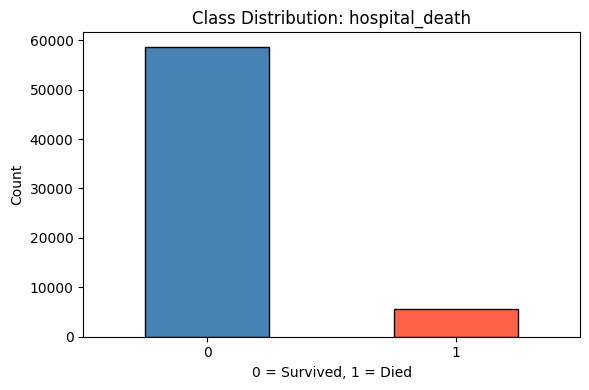

Saved: step0_class_distribution.png


In [13]:
# ============================================================
# STEP 2: TARGET COLUMN CHECK
# WHY: hospital_death is our target — check class balance
#      before any modeling. Imbalanced classes need special
#      handling (class_weight='balanced')
# ============================================================
print('TARGET COLUMN: hospital_death')
print('=' * 45)
counts = df['hospital_death'].value_counts()
pcts   = df['hospital_death'].value_counts(normalize=True) * 100
print(f'Survived (0): {counts[0]:,}  ({pcts[0]:.2f}%)')
print(f'Died     (1): {counts[1]:,}  ({pcts[1]:.2f}%)')

# Plot class distribution
plt.figure(figsize=(6, 4))
df['hospital_death'].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black'
)
plt.title('Class Distribution: hospital_death')
plt.xlabel('0 = Survived, 1 = Died')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('step0_class_distribution.png', dpi=150)
plt.show()
print('Saved: step0_class_distribution.png')

In [14]:
# ============================================================
# STEP 3: BASIC DATASET INFO
# WHY: Understand data types and get a quick summary of
#      numeric columns (mean, std, min, max)
# ============================================================
print('DATA TYPES:')
print(df.dtypes.value_counts())
print(f'\nNumeric columns : {df.select_dtypes(include=np.number).shape[1]}')
print(f'Object columns  : {df.select_dtypes(include="object").shape[1]}')
print(f'\nFirst 3 rows:')
df.head(3)

DATA TYPES:
float64    70
int64       7
object      7
Name: count, dtype: int64

Numeric columns : 77
Object columns  : 7

First 3 rows:


,encounter_id,patient_id,hospital_id,age,bmi,elective_surgery,ethnicity,gender,height,icu_admit_source,...,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem,hospital_death
0,36751,69039,158,66.0,35.693127,0,Caucasian,F,152.4,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory,0
1,68336,127397,47,48.0,18.966902,0,African American,F,165.1,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular,1
2,71682,77670,27,76.0,19.278960,0,Caucasian,M,173.0,Accident & Emergency,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,Sepsis,Cardiovascular,0


---
# PART 1 — Feature Selection
Three-step justification: Missing % → RF Importance → Correlation

MISSING VALUES PER COLUMN:
                               Missing Count  Missing %
d1_potassium_max                        6737      10.49
d1_potassium_min                        6737      10.49
h1_mbp_noninvasive_max                  6356       9.90
h1_mbp_noninvasive_min                  6356       9.90
apache_4a_icu_death_prob                5597       8.72
apache_4a_hospital_death_prob           5597       8.72
h1_diasbp_noninvasive_max               5144       8.01
h1_diasbp_noninvasive_min               5144       8.01
h1_sysbp_noninvasive_min                5137       8.00
h1_sysbp_noninvasive_max                5137       8.00
d1_glucose_max                          4075       6.35
d1_glucose_min                          4075       6.35
h1_mbp_min                              3229       5.03
h1_mbp_max                              3229       5.03
h1_resprate_max                         3021       4.71
h1_resprate_min                         3021       4.71
age                  

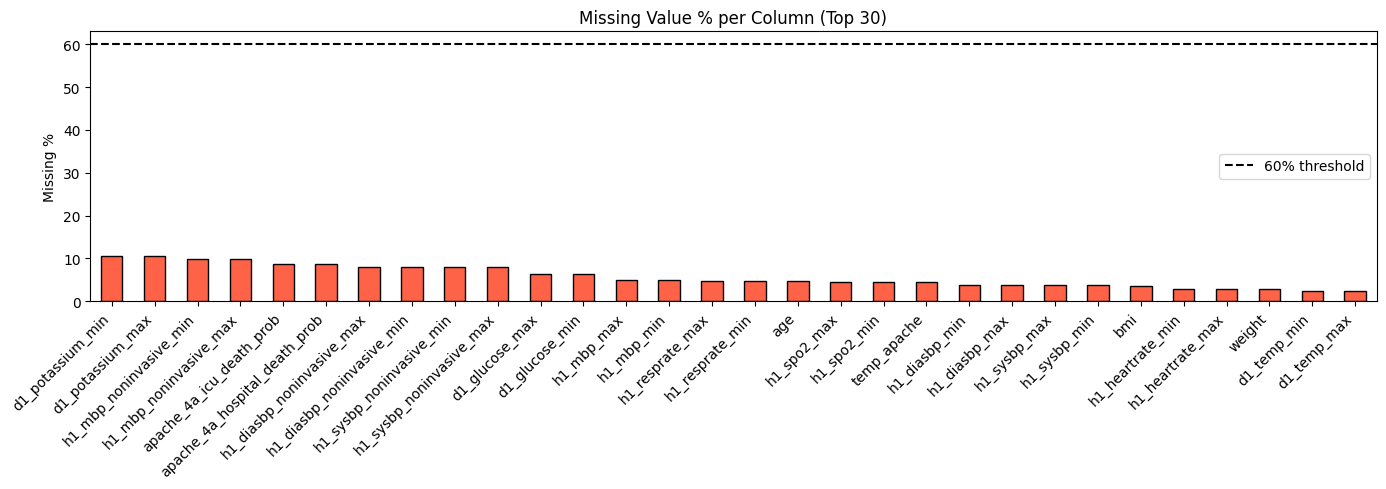

Saved: step1_missing_values.png

Columns dropped (>60% missing): 0
[]

Shape after missing drop: (64199, 84)


In [15]:
# ============================================================
# STEP 4: MISSING VALUE ANALYSIS
# WHY: Columns with >60% missing values are unreliable
#      predictors. Filling that many values with median
#      introduces too much noise. We drop them first.
# THRESHOLD: 60% (slightly lower than PhysioNet's 70%
#            because this dataset is smaller — 91k rows)
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import pointbiserialr

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print('MISSING VALUES PER COLUMN:')
print('=' * 50)
print(missing_df[missing_df['Missing %'] > 0].to_string())

# Plot top 30 missing
top_missing = missing_pct[missing_pct > 0].sort_values(ascending=False).head(30)
plt.figure(figsize=(14, 5))
top_missing.plot(kind='bar', color='tomato', edgecolor='black')
plt.axhline(y=60, color='black', linestyle='--', linewidth=1.5, label='60% threshold')
plt.title('Missing Value % per Column (Top 30)')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('step1_missing_values.png', dpi=150)
plt.show()
print('Saved: step1_missing_values.png')

# Drop columns >60% missing
safe_cols = ['hospital_death', 'encounter_id', 'patient_id']
drop_missing = [c for c in missing_pct[missing_pct > 60].index if c not in safe_cols]
print(f'\nColumns dropped (>60% missing): {len(drop_missing)}')
print(drop_missing)

df_clean = df.drop(columns=drop_missing)
print(f'\nShape after missing drop: {df_clean.shape}')

In [16]:
# ============================================================
# STEP 5: HANDLE CATEGORICAL COLUMNS BEFORE RF
# WHY: Random Forest only works on numeric data.
#      We encode categorical columns (gender, ethnicity etc.)
#      and drop ID columns that carry no medical meaning.
# ============================================================
# Drop pure ID columns — no predictive value
id_cols = ['encounter_id', 'patient_id', 'hospital_id', 'icu_id']
df_clean.drop(columns=[c for c in id_cols if c in df_clean.columns], inplace=True)

# Encode categorical columns with label encoding
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str)
    df_clean[col] = le.fit_transform(df_clean[col])

# Fill remaining NaN with median for RF
df_rf = df_clean.fillna(df_clean.median(numeric_only=True))

print(f'Shape ready for RF: {df_rf.shape}')
print(f'Missing values left: {df_rf.isnull().sum().sum()}')

Categorical columns to encode: ['ethnicity', 'gender', 'icu_admit_source', 'icu_stay_type', 'icu_type', 'apache_3j_bodysystem', 'apache_2_bodysystem']
Shape ready for RF: (64199, 80)
Missing values left: 0


Training Random Forest for feature importance...
(n_estimators=100, max_depth=10 — fast but reliable)

Top 30 Features by RF Importance:
apache_4a_icu_death_prob         0.153486
apache_4a_hospital_death_prob    0.137632
ventilated_apache                0.060924
gcs_verbal_apache                0.034329
gcs_motor_apache                 0.033901
d1_sysbp_noninvasive_min         0.030276
d1_sysbp_min                     0.029779
d1_mbp_min                       0.024746
d1_spo2_min                      0.023210
gcs_eyes_apache                  0.023185
apache_2_diagnosis               0.022931
age                              0.022453
d1_mbp_noninvasive_min           0.020409
apache_3j_diagnosis              0.019937
d1_heartrate_max                 0.017887
temp_apache                      0.014524
h1_resprate_min                  0.012676
d1_temp_min                      0.011953
d1_resprate_max                  0.011537
d1_diasbp_min                    0.011246
d1_heartrate_min       

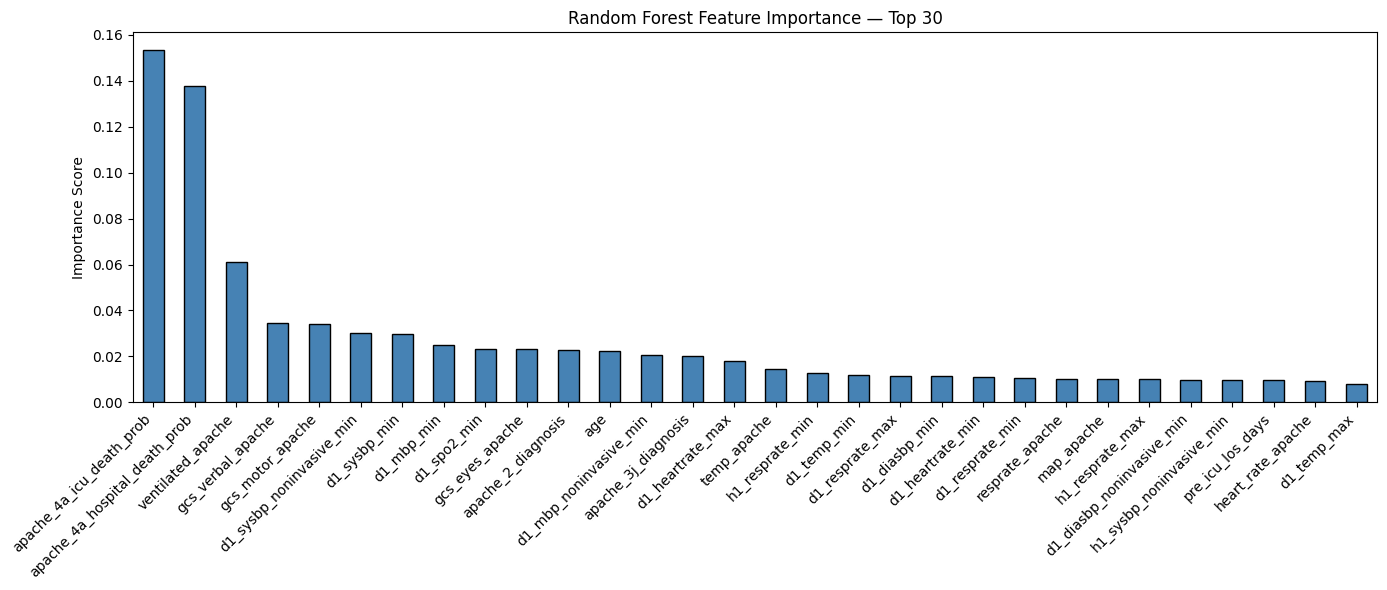

Saved: step2_rf_importance.png


In [17]:
# ============================================================
# STEP 6: RANDOM FOREST FEATURE IMPORTANCE
# WHY: RF ranks features by how much they reduce impurity
#      across all decision trees. High importance = strong
#      predictor of hospital_death. This is data-driven proof
#      for why we keep certain columns.
# ============================================================
X_rf = df_rf.drop(columns=['hospital_death'])
y_rf = df_rf['hospital_death']

print('Training Random Forest for feature importance...')
print('(n_estimators=100, max_depth=10 — fast but reliable)')

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf.fit(X_rf, y_rf)

importances = pd.Series(rf.feature_importances_, index=X_rf.columns)
importances = importances.sort_values(ascending=False)

print('\nTop 30 Features by RF Importance:')
print(importances.head(30).to_string())

# Plot top 30
plt.figure(figsize=(14, 6))
importances.head(30).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Random Forest Feature Importance — Top 30')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('step2_rf_importance.png', dpi=150)
plt.show()
print('Saved: step2_rf_importance.png')

Top 30 Features by |Correlation| with hospital_death:
apache_4a_hospital_death_prob    0.295575
apache_4a_icu_death_prob         0.270330
gcs_motor_apache                 0.267089
gcs_eyes_apache                  0.245897
gcs_verbal_apache                0.227138
ventilated_apache                0.222539
d1_sysbp_min                     0.206981
d1_sysbp_noninvasive_min         0.206100
d1_spo2_min                      0.202495
d1_temp_min                      0.197368
d1_mbp_min                       0.194190
d1_mbp_noninvasive_min           0.193352
d1_diasbp_min                    0.179572
d1_diasbp_noninvasive_min        0.179148
intubated_apache                 0.169439
d1_heartrate_max                 0.162172
temp_apache                      0.147154
h1_sysbp_noninvasive_min         0.142900
h1_mbp_noninvasive_min           0.142050
h1_sysbp_min                     0.141762
h1_mbp_min                       0.137581
h1_diasbp_noninvasive_min        0.127403
h1_diasbp_min         

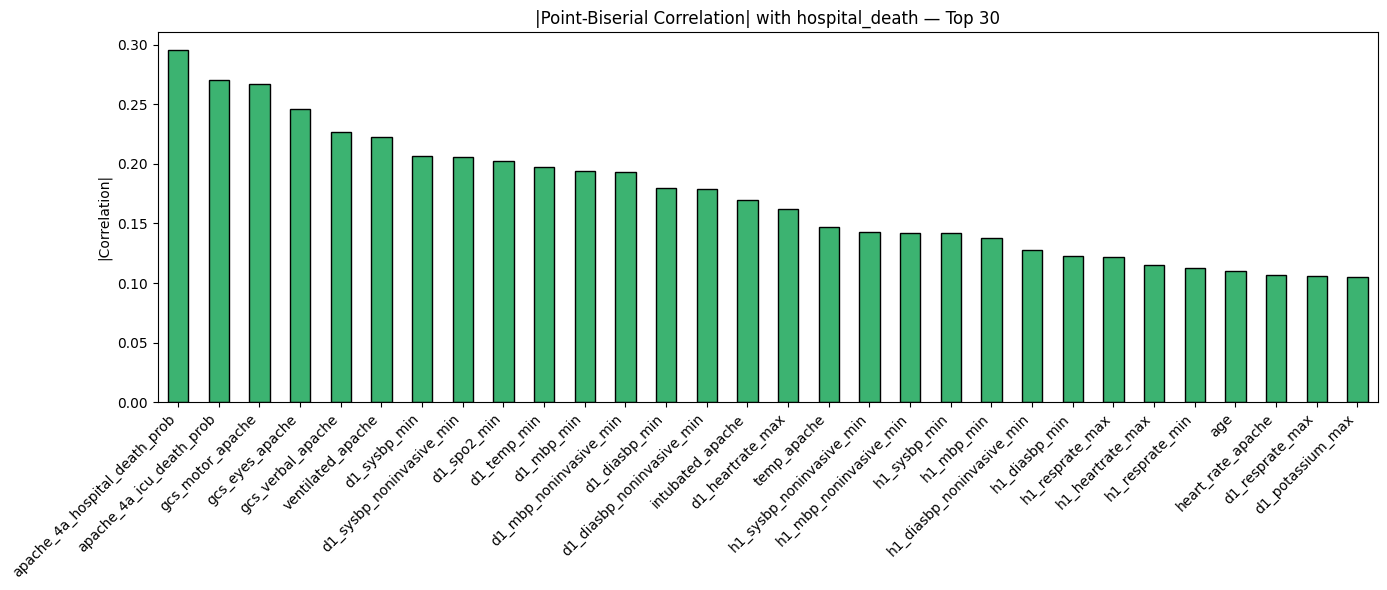

Saved: step3_correlation.png


In [18]:
# ============================================================
# STEP 7: POINT-BISERIAL CORRELATION WITH TARGET
# WHY: Point-biserial correlation measures linear relationship
#      between each feature and hospital_death (binary target).
#      Combines with RF importance to confirm column selection.
#      — High RF + High Corr -> definitely keep
#      — High RF + Low Corr  -> keep (RF is stronger evidence)
#      — Low RF + Low Corr   -> drop
# ============================================================
correlations = {}
for col in X_rf.columns:
    try:
        corr, _ = pointbiserialr(df_rf[col], df_rf['hospital_death'])
        correlations[col] = abs(corr)  # absolute value
    except:
        correlations[col] = 0

corr_series = pd.Series(correlations).sort_values(ascending=False)

print('Top 30 Features by |Correlation| with hospital_death:')
print(corr_series.head(30).to_string())

# Plot top 30
plt.figure(figsize=(14, 6))
corr_series.head(30).plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('|Point-Biserial Correlation| with hospital_death — Top 30')
plt.ylabel('|Correlation|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('step3_correlation.png', dpi=150)
plt.show()
print('Saved: step3_correlation.png')

In [19]:
# ============================================================
# STEP 8: COMBINED DECISION TABLE
# WHY: Show RF rank + Correlation rank side by side so we
#      can justify each kept column with two independent
#      statistical methods + clinical reasoning
# ============================================================
decision_df = pd.DataFrame({
    'RF_Importance': importances,
    'Correlation'  : corr_series
}).sort_values('RF_Importance', ascending=False)

print('TOP 40 COLUMNS — RF Importance + Correlation:')
print('=' * 55)
print(decision_df.head(40).round(4).to_string())

print('\n>> Share screenshots of:')
print('   step1_missing_values.png')
print('   step2_rf_importance.png')
print('   step3_correlation.png')
print('   + this terminal output')
print('Then we finalize which columns to keep.')

TOP 40 COLUMNS — RF Importance + Correlation:
                               RF_Importance  Correlation
apache_4a_icu_death_prob              0.1535       0.2703
apache_4a_hospital_death_prob         0.1376       0.2956
ventilated_apache                     0.0609       0.2225
gcs_verbal_apache                     0.0343       0.2271
gcs_motor_apache                      0.0339       0.2671
d1_sysbp_noninvasive_min              0.0303       0.2061
d1_sysbp_min                          0.0298       0.2070
d1_mbp_min                            0.0247       0.1942
d1_spo2_min                           0.0232       0.2025
gcs_eyes_apache                       0.0232       0.2459
apache_2_diagnosis                    0.0229       0.0913
age                                   0.0225       0.1100
d1_mbp_noninvasive_min                0.0204       0.1934
apache_3j_diagnosis                   0.0199       0.0907
d1_heartrate_max                      0.0179       0.1622
temp_apache               

In [21]:
# ============================================================
# STEP 9: SELECT FINAL COLUMNS & SAVE Dataset_final.csv
# WHY: Based on RF importance + correlation + clinical
#      literature, we keep the most predictive features.
#      Clinical justification (APACHE, GCS, vitals) matches
#      real ICU scoring systems used worldwide.
# ============================================================

final_features = [
    'apache_4a_hospital_death_prob',
    'apache_4a_icu_death_prob',
    'heart_rate_apache',
    'map_apache',
    'resprate_apache',
    'temp_apache',
    'gcs_eyes_apache',
    'gcs_motor_apache',
    'gcs_verbal_apache',
    'd1_heartrate_max',
    'd1_heartrate_min',
    'd1_sysbp_max',
    'd1_sysbp_min',
    'd1_mbp_max',
    'd1_mbp_min',
    'd1_diasbp_max',
    'd1_diasbp_min',
    'd1_resprate_max',
    'd1_resprate_min',
    'd1_spo2_max',
    'd1_spo2_min',
    'd1_temp_max',
    'd1_temp_min',
    'h1_heartrate_max',
    'h1_heartrate_min',
    'h1_sysbp_max',
    'h1_sysbp_min',
    'h1_spo2_min',
    'h1_resprate_max',
    'age',
    'bmi',
    'pre_icu_los_days',
    'elective_surgery',
    'apache_post_operative',
    'diabetes_mellitus',
    'immunosuppression',
    'cirrhosis',
    'solid_tumor_with_metastasis',
]

final_features = [c for c in final_features if c in df.columns]
print(f'Final features selected: {len(final_features)}')
print(final_features)

keep_cols = final_features + ['hospital_death']
df_final = df[keep_cols].copy()

print(f'\nFinal dataset shape: {df_final.shape}')
print(f'\nMissing values before fill:')
print(df_final.isnull().sum()[df_final.isnull().sum() > 0])

for col in df_final.columns:
    if df_final[col].isnull().any():
        df_final[col].fillna(df_final[col].median(), inplace=True)

print(f'\nMissing values after fill: {df_final.isnull().sum().sum()}')

counts = df_final['hospital_death'].value_counts()
pcts   = df_final['hospital_death'].value_counts(normalize=True) * 100
print(f'Survived (0): {counts[0]:,}  ({pcts[0]:.2f}%)')
print(f'Died     (1): {counts[1]:,}  ({pcts[1]:.2f}%)')

df_final.to_csv('Dataset_final.csv', index=False)
print(f'\nSaved: Dataset_final.csv')
print(f'   Rows    : {df_final.shape[0]:,}')
print(f'   Columns : {df_final.shape[1]}')

Final features selected: 38
['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob', 'heart_rate_apache', 'map_apache', 'resprate_apache', 'temp_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_temp_max', 'd1_temp_min', 'h1_heartrate_max', 'h1_heartrate_min', 'h1_sysbp_max', 'h1_sysbp_min', 'h1_spo2_min', 'h1_resprate_max', 'age', 'bmi', 'pre_icu_los_days', 'elective_surgery', 'apache_post_operative', 'diabetes_mellitus', 'immunosuppression', 'cirrhosis', 'solid_tumor_with_metastasis']

Final dataset shape: (64199, 39)

Missing values before fill:
apache_4a_hospital_death_prob    5597
apache_4a_icu_death_prob         5597
heart_rate_apache                 625
map_apache                        713
resprate_apache                   890
temp_apache              

---
# PART 2 — Generation 1: Deep Neural Network (DNN)
**Two models:** DNN + SGD vs DNN + Adam
Both use Dropout + Batch Normalization + class_weight='balanced'

In [22]:
# ============================================================
# STEP 10: IMPORTS FOR DEEP LEARNING
# ============================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD, Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import time

print(f'TensorFlow version: {tf.__version__}')
print('Deep learning libraries loaded')

TensorFlow version: 2.21.0
Deep learning libraries loaded


In [23]:
# ============================================================
# STEP 11: LOAD FINAL DATASET & PREPARE FEATURES
# ============================================================
df1 = pd.read_csv('Dataset_final.csv')

feature_cols = [c for c in df1.columns if c != 'hospital_death']
target_col   = 'hospital_death'

X = df1[feature_cols].values
y = df1[target_col].values

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'\nClass distribution:')
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {int(u)}: {c:,} ({c/len(y)*100:.2f}%)')

Features shape : (64199, 38)
Target shape   : (64199,)
Feature columns (38): ['apache_4a_hospital_death_prob', 'apache_4a_icu_death_prob', 'heart_rate_apache', 'map_apache', 'resprate_apache', 'temp_apache', 'gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache', 'd1_heartrate_max', 'd1_heartrate_min', 'd1_sysbp_max', 'd1_sysbp_min', 'd1_mbp_max', 'd1_mbp_min', 'd1_diasbp_max', 'd1_diasbp_min', 'd1_resprate_max', 'd1_resprate_min', 'd1_spo2_max', 'd1_spo2_min', 'd1_temp_max', 'd1_temp_min', 'h1_heartrate_max', 'h1_heartrate_min', 'h1_sysbp_max', 'h1_sysbp_min', 'h1_spo2_min', 'h1_resprate_max', 'age', 'bmi', 'pre_icu_los_days', 'elective_surgery', 'apache_post_operative', 'diabetes_mellitus', 'immunosuppression', 'cirrhosis', 'solid_tumor_with_metastasis']

Class distribution:
  Class 0: 58,659 (91.37%)
  Class 1: 5,540 (8.63%)


In [24]:
# ============================================================
# STEP 12: TRAIN/VAL/TEST SPLIT + NORMALIZE
# WHY: 70/15/15 split. StandardScaler fit only on train.
# ============================================================
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f'Train size : {X_train.shape[0]:,}')
print(f'Val size   : {X_val.shape[0]:,}')
print(f'Test size  : {X_test.shape[0]:,}')
print(f'Train mean (should be ~0): {X_train.mean():.2f}')
print(f'Train std  (should be ~1): {X_train.std():.2f}')

Train size : 44,937
Val size   : 9,632
Test size  : 9,630
Train mean (should be ~0): -0.00
Train std  (should be ~1): 1.00


In [25]:
# ============================================================
# STEP 13: COMPUTE CLASS WEIGHTS
# WHY: hospital_death is imbalanced (~8-9% deaths).
#      Died (1) gets higher weight — catches more deaths.
# ============================================================
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced', classes=classes, y=y_train
)
class_weight_dict = dict(zip(classes.astype(int), weights))

print(f'Class weights: {class_weight_dict}')
ratio = weights[1] / weights[0]
print(f'>> Died (1) gets {ratio:.1f}x more weight')

Class weights: {0: 0.5472247253951631, 1: 5.793837029396596}
>> Died (1) gets 10.6x more weight


In [26]:
# ============================================================
# STEP 14: BUILD DNN ARCHITECTURE
# 3 hidden layers: 256->128->64, BN + Dropout(0.3), Sigmoid output
# ============================================================
n_features = X_train.shape[1]

def build_dnn(optimizer, learning_rate=0.001):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(n_features,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    if optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = Adam(learning_rate=learning_rate)
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

demo_model = build_dnn('adam')
demo_model.summary()
print(f'\nInput features: {n_features}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,993 (207.00 KB)

 Trainable params: 52,097 (203.50 KB)

 Non-trainable params: 896 (3.50 KB)


Input features: 38


In [27]:
# ============================================================
# STEP 15: TRAIN MODEL 1 — DNN + SGD
# WHY SGD: Classic optimizer with momentum=0.9.
# EarlyStopping patience=5 on val_loss.
# ============================================================
print('Training Model 1: DNN + SGD')
print('=' * 45)

early_stop = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

model_sgd = build_dnn('sgd', learning_rate=0.01)

start = time.time()
history_sgd = model_sgd.fit(
    X_train, y_train,
    epochs=50, batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop], verbose=1
)
sgd_time = time.time() - start
print(f'\nSGD Training time: {sgd_time:.1f} seconds')

Training Model 1: DNN + SGD
Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7472 - loss: 0.5402 - val_accuracy: 0.8686 - val_loss: 0.4040
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7803 - loss: 0.4763 - val_accuracy: 0.8456 - val_loss: 0.3841
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7885 - loss: 0.4666 - val_accuracy: 0.8135 - val_loss: 0.4187
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7804 - loss: 0.4590 - val_accuracy: 0.8045 - val_loss: 0.4085
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7835 - loss: 0.4534 - val_accuracy: 0.8077 - val_loss: 0.4060
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7827 - loss: 0.4495 - val_accuracy: 0.8185 - val_loss: 0.3985
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7853 - loss: 0.4465 - val_accuracy: 0.8021 - val_loss: 0.4073
Epoch 7: early stopping
Restoring model weights from the end of the b

In [28]:
# ============================================================
# STEP 16: TRAIN MODEL 2 — DNN + Adam
# WHY Adam: Adaptive per-parameter LR. Faster convergence.
# ============================================================
print('Training Model 2: DNN + Adam')
print('=' * 45)

early_stop2 = EarlyStopping(
    monitor='val_loss', patience=5,
    restore_best_weights=True, verbose=1
)

model_adam = build_dnn('adam', learning_rate=0.001)

start = time.time()
history_adam = model_adam.fit(
    X_train, y_train,
    epochs=50, batch_size=256,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop2], verbose=1
)
adam_time = time.time() - start
print(f'\nAdam Training time: {adam_time:.1f} seconds')

Training Model 2: DNN + Adam
Epoch 1/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.6989 - loss: 0.5896 - val_accuracy: 0.8286 - val_loss: 0.4191
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7648 - loss: 0.4943 - val_accuracy: 0.8004 - val_loss: 0.4295
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7718 - loss: 0.4680 - val_accuracy: 0.8048 - val_loss: 0.4139
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7791 - loss: 0.4570 - val_accuracy: 0.7837 - val_loss: 0.4427
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7752 - loss: 0.4534 - val_accuracy: 0.7907 - val_loss: 0.4248
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7776 - loss: 0.4461 - val_accuracy: 0.7915 - val_loss: 0.4204
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7808 - loss: 0.4393 - val_accuracy: 0.7940 - val_loss: 0.4234
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7

In [29]:
# ============================================================
# STEP 17: EVALUATE GEN 1 MODELS
# Recall is most important: missed deaths > false alarms
# ============================================================
def evaluate_model(model, X_test, y_test, name, train_time):
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f'{name} Results:')
    print('=' * 45)
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}  <- most important in healthcare')
    print(f'  F1 Score  : {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))
    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1 Score': round(f1,4), 'Train Time (s)': round(train_time,1)}

res_sgd  = evaluate_model(model_sgd,  X_test, y_test, 'DNN + SGD',  sgd_time)
res_adam = evaluate_model(model_adam, X_test, y_test, 'DNN + Adam', adam_time)

gen1_results = pd.DataFrame([res_sgd, res_adam])
print('\nGen 1 — Model Comparison Table')
print(gen1_results.to_string(index=False))
gen1_results.to_csv('gen1_results.csv', index=False)
print('Saved: gen1_results.csv')

DNN + SGD Results:
  Accuracy  : 0.8440
  Precision : 0.3168
  Recall    : 0.6980  <- most important in healthcare
  F1 Score  : 0.4358
              precision    recall  f1-score   support

    Survived       0.97      0.86      0.91      8799
        Died       0.32      0.70      0.44       831

    accuracy                           0.84      9630
   macro avg       0.64      0.78      0.67      9630
weighted avg       0.91      0.84      0.87      9630

DNN + Adam Results:
  Accuracy  : 0.8025
  Precision : 0.2741
  Recall    : 0.7822  <- most important in healthcare
  F1 Score  : 0.4060
              precision    recall  f1-score   support

    Survived       0.98      0.80      0.88      8799
        Died       0.27      0.78      0.41       831

    accuracy                           0.80      9630
   macro avg       0.62      0.79      0.64      9630
weighted avg       0.91      0.80      0.84      9630


Gen 1 — Model Comparison Table
     Model  Accuracy  Precision  Recall  

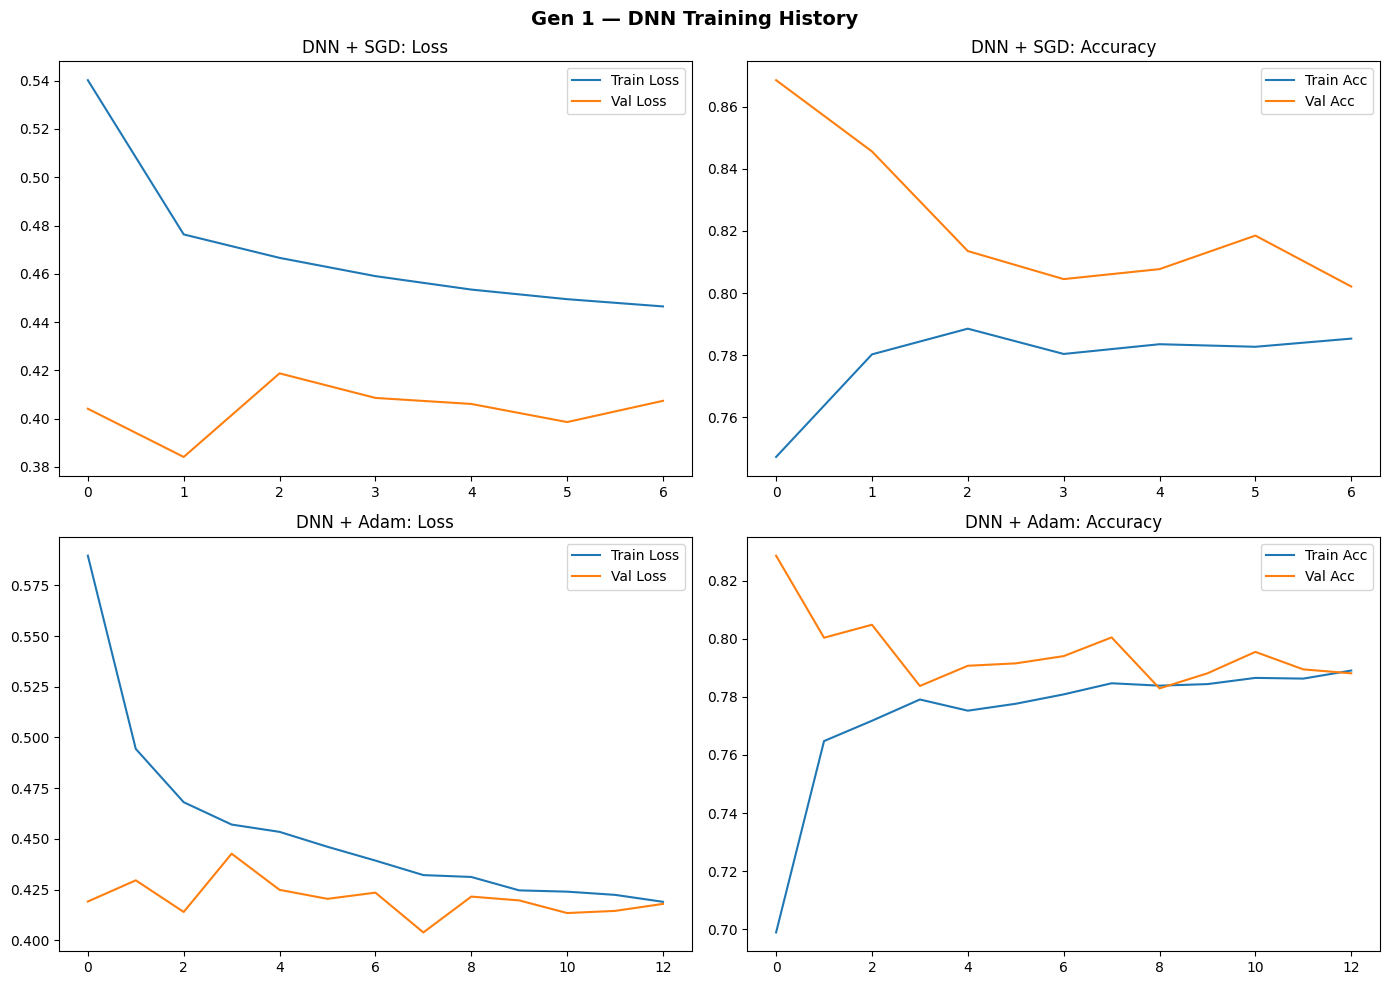

Saved: gen1_training_history.png


In [30]:
# ============================================================
# STEP 18: TRAINING HISTORY PLOTS — Gen 1
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(history_sgd.history['loss'],     label='Train Loss')
axes[0,0].plot(history_sgd.history['val_loss'], label='Val Loss')
axes[0,0].set_title('DNN + SGD: Loss'); axes[0,0].legend()

axes[0,1].plot(history_sgd.history['accuracy'],     label='Train Acc')
axes[0,1].plot(history_sgd.history['val_accuracy'], label='Val Acc')
axes[0,1].set_title('DNN + SGD: Accuracy'); axes[0,1].legend()

axes[1,0].plot(history_adam.history['loss'],     label='Train Loss')
axes[1,0].plot(history_adam.history['val_loss'], label='Val Loss')
axes[1,0].set_title('DNN + Adam: Loss'); axes[1,0].legend()

axes[1,1].plot(history_adam.history['accuracy'],     label='Train Acc')
axes[1,1].plot(history_adam.history['val_accuracy'], label='Val Acc')
axes[1,1].set_title('DNN + Adam: Accuracy'); axes[1,1].legend()

plt.suptitle('Gen 1 — DNN Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('gen1_training_history.png', dpi=150)
plt.show()
print('Saved: gen1_training_history.png')

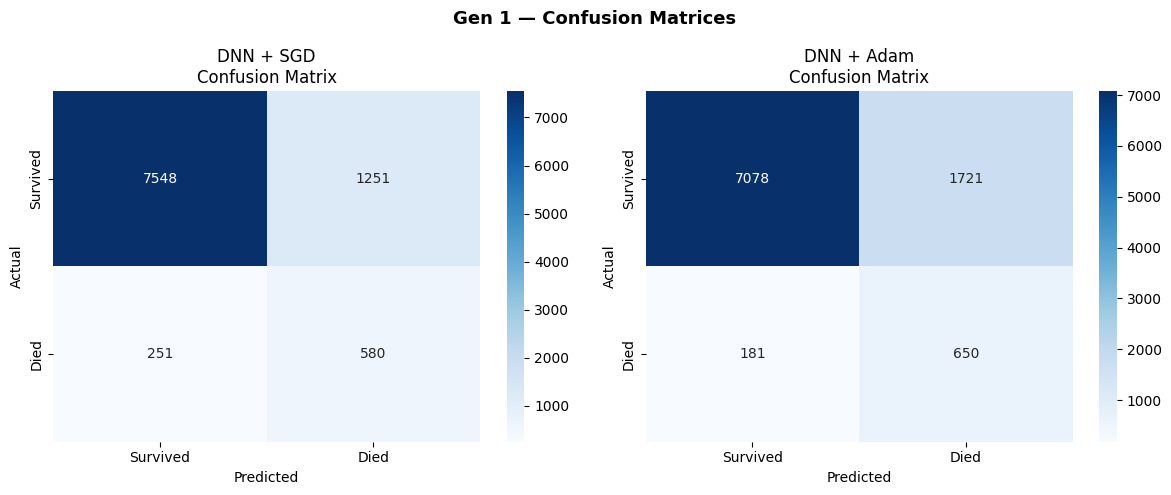

Saved: gen1_confusion_matrices.png


In [31]:
# ============================================================
# STEP 19: CONFUSION MATRICES — Gen 1
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, name in [
    (axes[0], model_sgd,  'DNN + SGD'),
    (axes[1], model_adam, 'DNN + Adam')
]:
    y_pred = (model.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Survived', 'Died'], yticklabels=['Survived', 'Died'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('Gen 1 — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gen1_confusion_matrices.png', dpi=150)
plt.show()
print('Saved: gen1_confusion_matrices.png')

---
# PART 3 — Generation 2: Time-Series Models (LSTM / Bi-LSTM / GRU)
**Strategy:** Use d1 (Day 1) and h1 (Hour 1) columns as 2 timesteps per patient

In [32]:
# ============================================================
# STEP 20: RESHAPE DATA INTO SEQUENCES FOR LSTM
# WHY: LSTM expects (samples, timesteps, features)
#   Timestep 1 = h1 vitals (hour 1)
#   Timestep 2 = d1 vitals (day 1)
# ============================================================
from tensorflow.keras.layers import LSTM, Bidirectional, GRU

df2 = pd.read_csv('Dataset_final.csv')

vital_types = ['heartrate', 'sysbp', 'diasbp', 'mbp', 'resprate', 'spo2']

h1_cols = [c for c in df2.columns if c.startswith('h1_') and any(v in c for v in vital_types)]
d1_cols = [c for c in df2.columns if c.startswith('d1_') and any(v in c for v in vital_types)]

seq_features = sorted(list(set(
    [c.replace('h1_','') for c in h1_cols]
).intersection(
    [c.replace('d1_','') for c in d1_cols]
)))

h1_final = ['h1_' + f for f in seq_features if 'h1_' + f in df2.columns]
d1_final = ['d1_' + f for f in seq_features if 'd1_' + f in df2.columns]

print(f'H1 columns (timestep 1): {len(h1_final)}')
print(h1_final)
print(f'\nD1 columns (timestep 2): {len(d1_final)}')
print(d1_final)

n_seq_features = len(h1_final)
print(f'\nSequence shape will be: (N_patients, 2, {n_seq_features})')

H1 columns (timestep 1): 6
['h1_heartrate_max', 'h1_heartrate_min', 'h1_resprate_max', 'h1_spo2_min', 'h1_sysbp_max', 'h1_sysbp_min']

D1 columns (timestep 2): 6
['d1_heartrate_max', 'd1_heartrate_min', 'd1_resprate_max', 'd1_spo2_min', 'd1_sysbp_max', 'd1_sysbp_min']

Sequence shape will be: (N_patients, 2, 6)


In [33]:
# ============================================================
# STEP 21: BUILD SEQUENCE ARRAY
# ============================================================
h1_vals = df2[h1_final].values
d1_vals = df2[d1_final].values
y_seq   = df2['hospital_death'].values

X_seq = np.stack([h1_vals, d1_vals], axis=1)

print(f'Sequence shape : {X_seq.shape}  (patients, timesteps, features)')
print(f'Labels shape   : {y_seq.shape}')

Sequence shape : (64199, 2, 6)  (patients, timesteps, features)
Labels shape   : (64199,)


In [34]:
# ============================================================
# STEP 22: FILL NAN, NORMALIZE SEQUENCES, SPLIT
# ============================================================
for i in range(X_seq.shape[2]):
    col_vals = X_seq[:, :, i].flatten()
    col_median = np.nanmedian(col_vals)
    X_seq[:, :, i] = np.where(np.isnan(X_seq[:, :, i]), col_median, X_seq[:, :, i])

orig_shape = X_seq.shape
seq_scaler = StandardScaler()

X_tmp, X_test_s, y_tmp, y_test_s = train_test_split(
    X_seq, y_seq, test_size=0.15, random_state=42, stratify=y_seq
)
X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_tmp, y_tmp, test_size=0.1765, random_state=42, stratify=y_tmp
)

tr_flat = X_train_s.reshape(-1, orig_shape[2])
seq_scaler.fit(tr_flat)

X_train_s = seq_scaler.transform(X_train_s.reshape(-1, orig_shape[2])).reshape(X_train_s.shape)
X_val_s   = seq_scaler.transform(X_val_s.reshape(-1,   orig_shape[2])).reshape(X_val_s.shape)
X_test_s  = seq_scaler.transform(X_test_s.reshape(-1,  orig_shape[2])).reshape(X_test_s.shape)

print(f'Train: {X_train_s.shape}')
print(f'Val  : {X_val_s.shape}')
print(f'Test : {X_test_s.shape}')

classes2 = np.unique(y_train_s)
weights2 = compute_class_weight('balanced', classes=classes2, y=y_train_s)
cw2      = dict(zip(classes2.astype(int), weights2))
print(f'Class weights: {cw2}')

Train: (44937, 2, 6)
Val  : (9632, 2, 6)
Test : (9630, 2, 6)
Class weights: {0: 0.5472247253951631, 1: 5.793837029396596}


In [35]:
# ============================================================
# STEP 23: TRAIN MODEL 3 — LSTM
# WHY: Gates (input/forget/output) capture temporal patterns.
# ============================================================
n_ts  = X_train_s.shape[1]
n_fts = X_train_s.shape[2]

def build_lstm():
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(n_ts, n_fts)),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print('Training Model 3: LSTM')
model_lstm = build_lstm()
model_lstm.summary()

es3 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
start = time.time()
history_lstm = model_lstm.fit(
    X_train_s, y_train_s, epochs=30, batch_size=256,
    validation_data=(X_val_s, y_val_s),
    class_weight=cw2, callbacks=[es3], verbose=1
)
lstm_time = time.time() - start
print(f'\nLSTM Training time: {lstm_time:.1f} seconds')

Training Model 3: LSTM


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 2, 64)          │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,137 (121.63 KB)

 Trainable params: 31,137 (121.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.6368 - loss: 0.6256 - val_accuracy: 0.7452 - val_loss: 0.5723
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7282 - loss: 0.5948 - val_accuracy: 0.7393 - val_loss: 0.5717
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7313 - loss: 0.5890 - val_accuracy: 0.7684 - val_loss: 0.5577
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7410 - loss: 0.5874 - val_accuracy: 0.7310 - val_loss: 0.5870
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7332 - loss: 0.5846 - val_accuracy: 0.7334 - val_loss: 0.5766
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7348 - loss: 0.5824 - val_accuracy: 0.7365 - val_loss: 0.5797
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7340 - loss: 0.5802 - val_accuracy: 0.7422 - val_loss: 0.5600
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7310 - loss: 0.5792 - val_acc

In [36]:
# ============================================================
# STEP 24: TRAIN MODEL 4 — Bidirectional LSTM
# WHY: Forward + backward pass captures richer patterns.
# ============================================================
def build_bilstm():
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=True), input_shape=(n_ts, n_fts)),
        Dropout(0.3),
        Bidirectional(LSTM(32, return_sequences=False)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print('Training Model 4: Bidirectional LSTM')
model_bilstm = build_bilstm()
model_bilstm.summary()

es4 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
start = time.time()
history_bilstm = model_bilstm.fit(
    X_train_s, y_train_s, epochs=30, batch_size=256,
    validation_data=(X_val_s, y_val_s),
    class_weight=cw2, callbacks=[es4], verbose=1
)
bilstm_time = time.time() - start
print(f'\nBi-LSTM Training time: {bilstm_time:.1f} seconds')

Training Model 4: Bidirectional LSTM


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 2, 128)         │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 2, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,625 (307.13 KB)

 Trainable params: 78,625 (307.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.6796 - loss: 0.6130 - val_accuracy: 0.7087 - val_loss: 0.6112
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7260 - loss: 0.5910 - val_accuracy: 0.7239 - val_loss: 0.5582
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7268 - loss: 0.5844 - val_accuracy: 0.7515 - val_loss: 0.5426
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7306 - loss: 0.5810 - val_accuracy: 0.7403 - val_loss: 0.5631
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7265 - loss: 0.5782 - val_accuracy: 0.7217 - val_loss: 0.5643
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7221 - loss: 0.5749 - val_accuracy: 0.7250 - val_loss: 0.5669
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7207 - loss: 0.5749 - val_accuracy: 0.7435 - val_loss: 0.5380
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7223 - loss: 0.5722 - val_acc

In [37]:
# ============================================================
# STEP 25: TRAIN MODEL 5 — GRU
# WHY: Fewer gates than LSTM, faster, often equal performance.
# ============================================================
def build_gru():
    model = Sequential([
        GRU(64, return_sequences=True, input_shape=(n_ts, n_fts)),
        Dropout(0.3),
        GRU(32, return_sequences=False),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

print('Training Model 5: GRU')
model_gru = build_gru()
model_gru.summary()

es5 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
start = time.time()
history_gru = model_gru.fit(
    X_train_s, y_train_s, epochs=30, batch_size=256,
    validation_data=(X_val_s, y_val_s),
    class_weight=cw2, callbacks=[es5], verbose=1
)
gru_time = time.time() - start
print(f'\nGRU Training time: {gru_time:.1f} seconds')

Training Model 5: GRU


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 2, 64)          │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,777 (92.88 KB)

 Trainable params: 23,777 (92.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6883 - loss: 0.6162 - val_accuracy: 0.7436 - val_loss: 0.5610
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7270 - loss: 0.5946 - val_accuracy: 0.7345 - val_loss: 0.5762
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7329 - loss: 0.5891 - val_accuracy: 0.7418 - val_loss: 0.5777
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7369 - loss: 0.5874 - val_accuracy: 0.7214 - val_loss: 0.6020
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7339 - loss: 0.5847 - val_accuracy: 0.7453 - val_loss: 0.5586
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7393 - loss: 0.5834 - val_accuracy: 0.7328 - val_loss: 0.5824
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7342 - loss: 0.5810 - val_accuracy: 0.7387 - val_loss: 0.5641
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7331 - loss: 0.5796 - val_accuracy: 0.

In [38]:
# ============================================================
# STEP 26: EVALUATE ALL GEN 2 MODELS
# ============================================================
def evaluate_seq_model(model, X_test, y_test, name, train_time):
    y_pred = (model.predict(X_test, verbose=0).flatten() >= 0.5).astype(int)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    print(f'{name} Results:')
    print(f'  Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=['Survived', 'Died']))
    return {'Model': name, 'Accuracy': round(acc,4), 'Precision': round(prec,4),
            'Recall': round(rec,4), 'F1 Score': round(f1,4), 'Train Time (s)': round(train_time,1)}

res_lstm   = evaluate_seq_model(model_lstm,   X_test_s, y_test_s, 'LSTM',               lstm_time)
res_bilstm = evaluate_seq_model(model_bilstm, X_test_s, y_test_s, 'Bidirectional LSTM', bilstm_time)
res_gru    = evaluate_seq_model(model_gru,    X_test_s, y_test_s, 'GRU',                gru_time)

gen2_results = pd.DataFrame([res_lstm, res_bilstm, res_gru])
print('\nGen 2 — Model Comparison Table')
print(gen2_results.to_string(index=False))
gen2_results.to_csv('gen2_results.csv', index=False)
print('Saved: gen2_results.csv')

LSTM Results:
  Accuracy: 0.7586  Precision: 0.2059  Recall: 0.6294  F1: 0.3103
              precision    recall  f1-score   support

    Survived       0.96      0.77      0.85      8799
        Died       0.21      0.63      0.31       831

    accuracy                           0.76      9630
   macro avg       0.58      0.70      0.58      9630
weighted avg       0.89      0.76      0.81      9630

Bidirectional LSTM Results:
  Accuracy: 0.7430  Precision: 0.2020  Recall: 0.6703  F1: 0.3104
              precision    recall  f1-score   support

    Survived       0.96      0.75      0.84      8799
        Died       0.20      0.67      0.31       831

    accuracy                           0.74      9630
   macro avg       0.58      0.71      0.58      9630
weighted avg       0.89      0.74      0.80      9630

GRU Results:
  Accuracy: 0.7769  Precision: 0.2175  Recall: 0.6101  F1: 0.3207
              precision    recall  f1-score   support

    Survived       0.96      0.79     

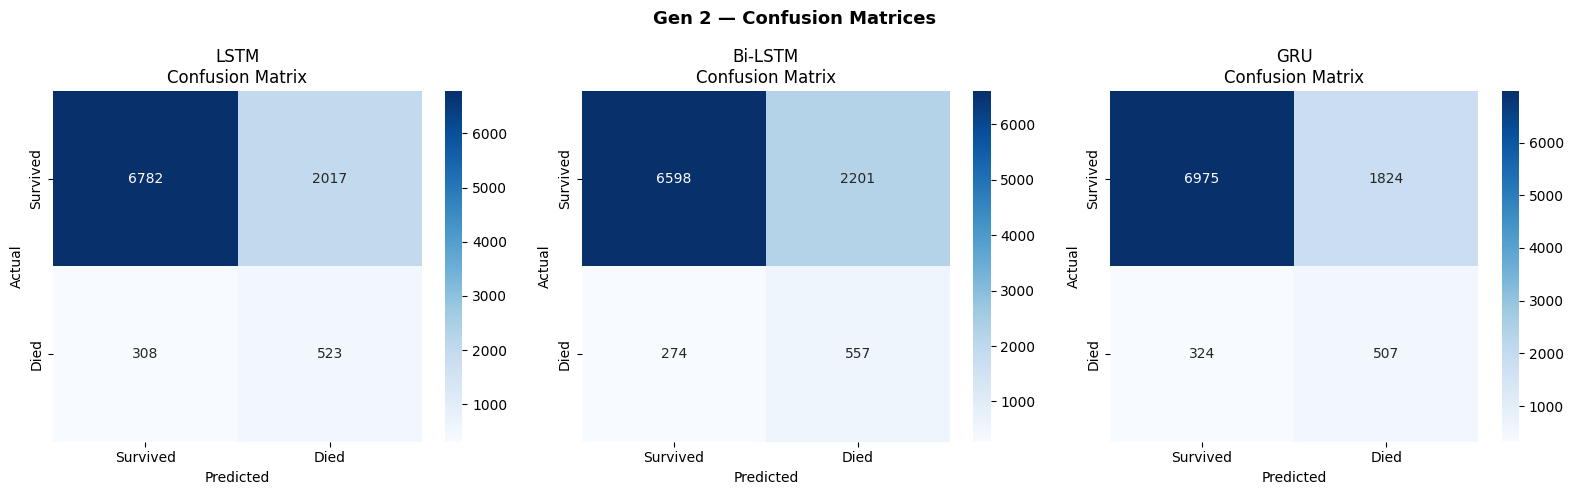

Saved: gen2_confusion_matrices.png


In [39]:
# ============================================================
# STEP 27: CONFUSION MATRICES — Gen 2
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model, name in [
    (axes[0], model_lstm,   'LSTM'),
    (axes[1], model_bilstm, 'Bi-LSTM'),
    (axes[2], model_gru,    'GRU')
]:
    y_pred = (model.predict(X_test_s, verbose=0).flatten() >= 0.5).astype(int)
    cm = confusion_matrix(y_test_s, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Survived','Died'], yticklabels=['Survived','Died'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('Gen 2 — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gen2_confusion_matrices.png', dpi=150)
plt.show()
print('Saved: gen2_confusion_matrices.png')

---
# PART 4 — Generation 3: ClinicalBERT (Text Classification)
Generate synthetic clinical notes from vitals then train BERT.

**Model 6a:** ClinicalBERT Frozen (only classifier head trains)

**Model 6b:** ClinicalBERT Full Fine-Tune (all 108M params train)

In [40]:
# ============================================================
# STEP 28: IMPORTS FOR BERT
# INSTALL: pip install transformers==4.36.0 tokenizers==0.15.0
# ============================================================
import os
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = 'true'

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device     : {device}')
print(f'PyTorch version  : {torch.__version__}')
import transformers
print(f'Transformers ver : {transformers.__version__}')
print('BERT libraries loaded')

Using device     : cpu
PyTorch version  : 2.2.0+cpu
Transformers ver : 4.36.0
BERT libraries loaded


In [41]:
# ============================================================
# STEP 29: GENERATE SYNTHETIC CLINICAL NOTES
# WHY: No clinical text in dataset — convert vitals to
#      doctor-style notes using Sepsis-3/GCS/APACHE thresholds.
#      'death'/'survived' NEVER written (prevents data leakage).
# ============================================================
def generate_clinical_note(row):
    parts = []
    if 'heart_rate_apache' in row and not pd.isna(row.get('heart_rate_apache', float('nan'))):
        hr = row['heart_rate_apache']
        if hr > 100: parts.append(f'Tachycardia noted, heart rate {hr:.0f} bpm.')
        elif hr < 60: parts.append(f'Bradycardia noted, heart rate {hr:.0f} bpm.')
        else: parts.append(f'Heart rate normal at {hr:.0f} bpm.')
    if 'temp_apache' in row and not pd.isna(row.get('temp_apache', float('nan'))):
        temp = row['temp_apache']
        if temp > 38.3: parts.append(f'Fever present, temperature {temp:.1f}C, infection suspected.')
        elif temp < 36.0: parts.append(f'Hypothermia noted, temperature {temp:.1f}C.')
        else: parts.append(f'Temperature normal at {temp:.1f}C.')
    if 'resprate_apache' in row and not pd.isna(row.get('resprate_apache', float('nan'))):
        resp = row['resprate_apache']
        if resp > 20: parts.append(f'Tachypnea observed, respiratory rate {resp:.0f} breaths/min.')
        elif resp < 12: parts.append(f'Bradypnea noted, respiratory rate {resp:.0f} breaths/min.')
        else: parts.append(f'Respiratory rate stable at {resp:.0f} breaths/min.')
    if 'map_apache' in row and not pd.isna(row.get('map_apache', float('nan'))):
        mp = row['map_apache']
        if mp < 65: parts.append(f'Critically low MAP {mp:.0f} mmHg, hypoperfusion risk.')
        elif mp > 110: parts.append(f'Elevated MAP {mp:.0f} mmHg, hypertensive.')
        else: parts.append(f'Mean arterial pressure acceptable at {mp:.0f} mmHg.')
    gcs_cols = ['gcs_eyes_apache', 'gcs_motor_apache', 'gcs_verbal_apache']
    if all(c in row.index for c in gcs_cols):
        total_gcs = sum([row.get(c, 0) or 0 for c in gcs_cols])
        if total_gcs <= 8: parts.append(f'Severe neurological impairment, GCS {total_gcs:.0f}.')
        elif total_gcs <= 12: parts.append(f'Moderate altered consciousness, GCS {total_gcs:.0f}.')
        else: parts.append(f'GCS {total_gcs:.0f}, patient conscious and responsive.')
    if 'apache_4a_hospital_death_prob' in row:
        prob = row.get('apache_4a_hospital_death_prob', 0.0) or 0.0
        if prob > 0.5: parts.append(f'APACHE score indicates high risk, predicted probability {prob:.2f}.')
        elif prob > 0.2: parts.append(f'APACHE score indicates moderate risk, probability {prob:.2f}.')
        else: parts.append(f'APACHE score indicates low risk, probability {prob:.2f}.')
    if 'age' in row: parts.append(f'Patient age {row["age"]:.0f} years.')
    if row.get('diabetes_mellitus', 0) == 1: parts.append('History of diabetes mellitus.')
    if row.get('immunosuppression', 0) == 1: parts.append('Patient is immunosuppressed.')
    if row.get('cirrhosis', 0) == 1: parts.append('Known cirrhosis.')
    return ' '.join(parts) if parts else 'Patient admitted to ICU for monitoring.'

df3 = pd.read_csv('Dataset_final.csv')
df3_sample = df3.sample(n=min(5000, len(df3)), random_state=42).reset_index(drop=True)
df3_sample['clinical_note'] = df3_sample.apply(generate_clinical_note, axis=1)

print(f'Notes generated: {len(df3_sample)}')
print(df3_sample['hospital_death'].value_counts())

for i, (_, row) in enumerate(df3_sample.sample(5, random_state=99).iterrows()):
    print(f'\n--- Patient {i+1} ---')
    print(f'Label : {int(row["hospital_death"])} ({"DIED" if row["hospital_death"]==1 else "SURVIVED"})')
    print(f'Note  : {row["clinical_note"]}')

df3_sample.to_csv('df_sample_check.csv', index=False)
print('Saved: df_sample_check.csv')

Notes generated: 5000
hospital_death
0    4596
1     404
Name: count, dtype: int64

--- Patient 1 ---
Label : 0 (SURVIVED)
Note  : Heart rate normal at 94 bpm. Temperature normal at 36.7C. Tachypnea observed, respiratory rate 33 breaths/min. Elevated MAP 124 mmHg, hypertensive. GCS 15, patient conscious and responsive. APACHE score indicates low risk, probability 0.01. Patient age 57 years. Patient is immunosuppressed.

--- Patient 2 ---
Label : 0 (SURVIVED)
Note  : Heart rate normal at 88 bpm. Temperature normal at 36.2C. Tachypnea observed, respiratory rate 39 breaths/min. Mean arterial pressure acceptable at 108 mmHg. GCS 15, patient conscious and responsive. APACHE score indicates low risk, probability 0.04. Patient age 87 years.

--- Patient 3 ---
Label : 0 (SURVIVED)
Note  : Heart rate normal at 96 bpm. Temperature normal at 36.9C. Tachypnea observed, respiratory rate 28 breaths/min. Mean arterial pressure acceptable at 73 mmHg. Moderate altered consciousness, GCS 11. APACHE scor

In [42]:
# ============================================================
# STEP 30: LOAD ClinicalBERT TOKENIZER
# WHY: emilyalsentzer/Bio_ClinicalBERT pre-trained on MIMIC-III
#      — understands tachycardia, MAP, GCS terminology.
# ============================================================
MODEL_NAME = 'emilyalsentzer/Bio_ClinicalBERT'
print(f'Loading tokenizer: {MODEL_NAME}')
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print('Tokenizer loaded')

sample = df3_sample['clinical_note'].iloc[0]
tokens = tokenizer.encode(sample)
print(f'Sample note token length: {len(tokens)}')

Loading tokenizer: emilyalsentzer/Bio_ClinicalBERT
Tokenizer loaded
Sample note token length: 72


In [43]:
# ============================================================
# STEP 31: CREATE PYTORCH DATASET + DATALOADERS
# MAX_LEN=128 covers all notes (60-90 tokens typically)
# BATCH_SIZE=16 — smaller for BERT memory requirements
# ============================================================
MAX_LEN    = 128
BATCH_SIZE = 16

class ClinicalDataset(Dataset):
    def __init__(self, notes, labels, tokenizer, max_len):
        self.notes = notes; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self):
        return len(self.notes)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.notes[idx], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

X_notes = df3_sample['clinical_note'].tolist()
y_notes = df3_sample['hospital_death'].tolist()

Xn_tmp, Xn_test, yn_tmp, yn_test = train_test_split(
    X_notes, y_notes, test_size=0.15, random_state=42, stratify=y_notes
)
Xn_train, Xn_val, yn_train, yn_val = train_test_split(
    Xn_tmp, yn_tmp, test_size=0.1765, random_state=42, stratify=yn_tmp
)

train_loader = DataLoader(ClinicalDataset(Xn_train, yn_train, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(ClinicalDataset(Xn_val,   yn_val,   tokenizer, MAX_LEN), batch_size=BATCH_SIZE)
test_loader  = DataLoader(ClinicalDataset(Xn_test,  yn_test,  tokenizer, MAX_LEN), batch_size=BATCH_SIZE)

print(f'Train: {len(Xn_train)}  Val: {len(Xn_val)}  Test: {len(Xn_test)}')
print('DataLoaders ready')

Train: 3499  Val: 751  Test: 750
DataLoaders ready


In [44]:
# ============================================================
# STEP 32: HELPER FUNCTIONS — BERT TRAIN + EVALUATE
# Linear warmup scheduler + class-weighted loss
# ============================================================
def train_bert_model(model, train_loader, val_loader, epochs=3, lr=2e-5, model_name='BERT'):
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, eps=1e-8)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer,
        num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    yn_arr  = np.array(yn_train)
    cw_vals = compute_class_weight('balanced', classes=np.unique(yn_arr), y=yn_arr)
    cw_t    = torch.tensor(cw_vals, dtype=torch.float).to(device)
    loss_fn = torch.nn.CrossEntropyLoss(weight=cw_t)
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    for epoch in range(epochs):
        model.train()
        tr_loss, tr_correct, tr_total = 0, 0, 0
        for batch in train_loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            label = batch['label'].to(device)
            optimizer.zero_grad()
            outputs = model(input_ids=ids, attention_mask=mask)
            loss = loss_fn(outputs.logits, label)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); scheduler.step()
            tr_loss += loss.item()
            preds = outputs.logits.argmax(dim=1)
            tr_correct += (preds == label).sum().item()
            tr_total   += label.size(0)
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                ids   = batch['input_ids'].to(device)
                mask  = batch['attention_mask'].to(device)
                label = batch['label'].to(device)
                outputs = model(input_ids=ids, attention_mask=mask)
                loss = loss_fn(outputs.logits, label)
                val_loss += loss.item()
                preds = outputs.logits.argmax(dim=1)
                val_correct += (preds == label).sum().item()
                val_total   += label.size(0)
        tl = tr_loss/len(train_loader); ta = tr_correct/tr_total
        vl = val_loss/len(val_loader);  va = val_correct/val_total
        history['train_loss'].append(tl); history['train_acc'].append(ta)
        history['val_loss'].append(vl);   history['val_acc'].append(va)
        print(f'Epoch {epoch+1}/{epochs} | Train Loss:{tl:.4f} Acc:{ta:.4f} | Val Loss:{vl:.4f} Acc:{va:.4f}')
    return model, history

def evaluate_bert(model, test_loader, name, train_time):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            label = batch['label'].to(device)
            preds = model(input_ids=ids, attention_mask=mask).logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())
    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec  = recall_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)
    print(f'\n{name}: Acc={acc:.4f}  Prec={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}')
    print(classification_report(all_labels, all_preds, target_names=['Survived','Died']))
    return {'Model':name,'Accuracy':round(acc,4),'Precision':round(prec,4),
            'Recall':round(rec,4),'F1 Score':round(f1,4),'Train Time (s)':round(train_time,1)}, all_preds, all_labels

print('Helper functions ready')

Helper functions ready


In [45]:
# ============================================================
# STEP 33: TRAIN MODEL 6a — ClinicalBERT FROZEN
# Freeze all BERT layers, train only classifier head.
# Fast. Lower Recall expected.
# ============================================================
print('Loading ClinicalBERT for FROZEN training...')
model_frozen = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

for name, param in model_frozen.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_frozen.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

start = time.time()
model_frozen, history_frozen = train_bert_model(
    model_frozen, train_loader, val_loader, epochs=3, lr=2e-4, model_name='ClinicalBERT Frozen'
)
frozen_time = time.time() - start
print(f'\nFrozen BERT training time: {frozen_time:.1f} seconds')

Loading ClinicalBERT for FROZEN training...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 1,538 / 108,311,810 (0.00%)
Epoch 1/3 | Train Loss:0.6972 Acc:0.6968 | Val Loss:0.7433 Acc:0.0812
Epoch 2/3 | Train Loss:0.6848 Acc:0.7039 | Val Loss:0.6812 Acc:0.8575
Epoch 3/3 | Train Loss:0.6779 Acc:0.6831 | Val Loss:0.6761 Acc:0.9188

Frozen BERT training time: 20971.8 seconds


In [46]:
# ============================================================
# STEP 34: TRAIN MODEL 6b — ClinicalBERT FULL FINE-TUNE
# All 108M params adapt. Lower LR (2e-5) prevents catastrophic
# forgetting of clinical language pre-training.
# ============================================================
print('Loading ClinicalBERT for FULL FINE-TUNE...')
model_finetune = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

trainable = sum(p.numel() for p in model_finetune.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model_finetune.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

start = time.time()
model_finetune, history_finetune = train_bert_model(
    model_finetune, train_loader, val_loader, epochs=3, lr=2e-5, model_name='ClinicalBERT Fine-Tune'
)
finetune_time = time.time() - start
print(f'\nFull Fine-Tune training time: {finetune_time:.1f} seconds')

Loading ClinicalBERT for FULL FINE-TUNE...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 108,311,810 / 108,311,810 (100.00%)
Epoch 1/3 | Train Loss:0.6142 Acc:0.8548 | Val Loss:0.6648 Acc:0.9188
Epoch 2/3 | Train Loss:0.5383 Acc:0.8542 | Val Loss:0.7376 Acc:0.8975
Epoch 3/3 | Train Loss:0.5135 Acc:0.8571 | Val Loss:0.6049 Acc:0.8615

Full Fine-Tune training time: 8865.6 seconds


In [47]:
# ============================================================
# STEP 35: EVALUATE GEN 3 MODELS
# ============================================================
res_frozen,   preds_frozen,   labels_frozen   = evaluate_bert(model_frozen,   test_loader, 'ClinicalBERT Frozen',     frozen_time)
res_finetune, preds_finetune, labels_finetune = evaluate_bert(model_finetune, test_loader, 'ClinicalBERT Fine-Tune',  finetune_time)

gen3_results = pd.DataFrame([res_frozen, res_finetune])
print('\nGen 3 — Model Comparison Table')
print(gen3_results.to_string(index=False))
gen3_results.to_csv('gen3_results.csv', index=False)
print('Saved: gen3_results.csv')


ClinicalBERT Frozen: Acc=0.9187  Prec=0.0000  Recall=0.0000  F1=0.0000
              precision    recall  f1-score   support

    Survived       0.92      1.00      0.96       689
        Died       0.00      0.00      0.00        61

    accuracy                           0.92       750
   macro avg       0.46      0.50      0.48       750
weighted avg       0.84      0.92      0.88       750


ClinicalBERT Fine-Tune: Acc=0.8640  Prec=0.2929  Recall=0.4754  F1=0.3625
              precision    recall  f1-score   support

    Survived       0.95      0.90      0.92       689
        Died       0.29      0.48      0.36        61

    accuracy                           0.86       750
   macro avg       0.62      0.69      0.64       750
weighted avg       0.90      0.86      0.88       750


Gen 3 — Model Comparison Table
                 Model  Accuracy  Precision  Recall  F1 Score  Train Time (s)
   ClinicalBERT Frozen    0.9187     0.0000  0.0000    0.0000         20971.8
ClinicalBER

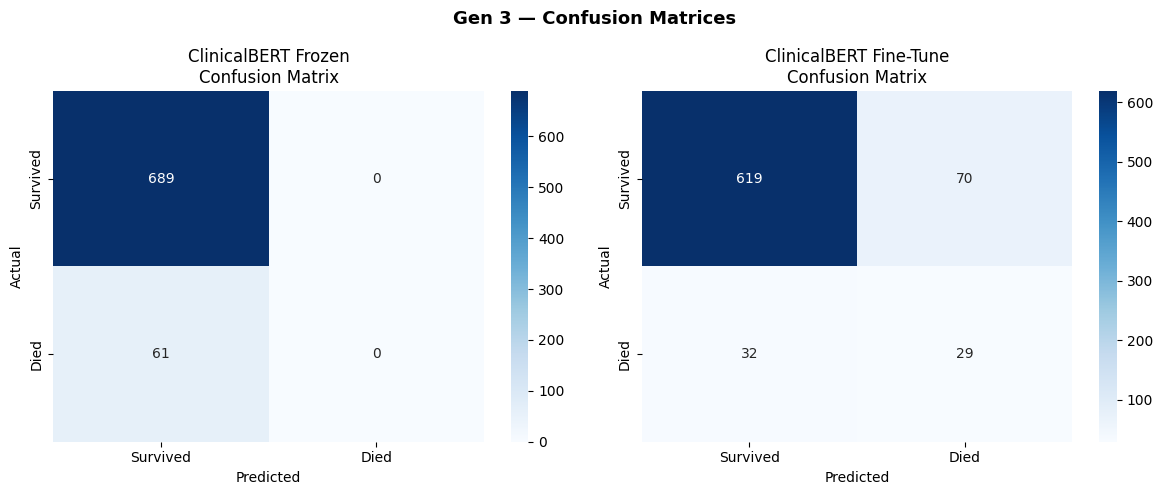

Saved: gen3_confusion_matrices.png


In [48]:
# ============================================================
# STEP 36: CONFUSION MATRICES — Gen 3
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, labels, name in [
    (axes[0], preds_frozen,   labels_frozen,   'ClinicalBERT Frozen'),
    (axes[1], preds_finetune, labels_finetune, 'ClinicalBERT Fine-Tune')
]:
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Survived','Died'], yticklabels=['Survived','Died'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('Gen 3 — Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gen3_confusion_matrices.png', dpi=150)
plt.show()
print('Saved: gen3_confusion_matrices.png')

Note: Tachycardia noted, heart rate 128 bpm. Temperature normal at 36.5C. Tachypnea observed, respiratory rate 54 breaths/min. Elevated MAP 161 mmHg, hypertensive. Severe neurological impairment, GCS 3. APACHE score indicates high risk, predicted probability 0.76. Patient age 62 years.


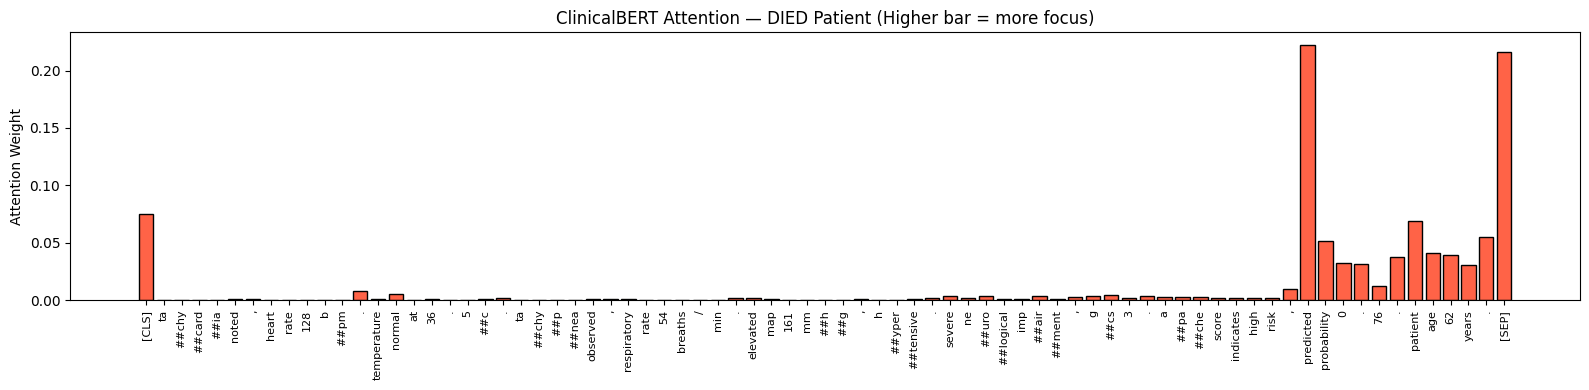

Saved: gen3_attention_heatmap.png


In [49]:
# ============================================================
# STEP 37: ATTENTION HEATMAP — Which words BERT focused on
# WHY: Explainability — doctors want to know WHY the model
#      predicted death. CLS token attention shows key words.
# ============================================================
model_finetune.eval()

died_idx = next(i for i, l in enumerate(yn_test) if l == 1)
sample_note = Xn_test[died_idx]
print(f'Note: {sample_note}')

enc = tokenizer(sample_note, max_length=MAX_LEN, padding='max_length',
                truncation=True, return_tensors='pt')

with torch.no_grad():
    output = model_finetune(
        input_ids=enc['input_ids'].to(device),
        attention_mask=enc['attention_mask'].to(device),
        output_attentions=True
    )

attention  = output.attentions[-1][0]
avg_attn   = attention.mean(dim=0)[0].cpu().numpy()

tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
real_mask   = enc['attention_mask'][0].numpy().astype(bool)
real_tokens = [t for t, m in zip(tokens, real_mask) if m]
real_attn   = avg_attn[:len(real_tokens)]

plt.figure(figsize=(16, 4))
plt.bar(range(len(real_tokens)), real_attn, color='tomato', edgecolor='black')
plt.xticks(range(len(real_tokens)), real_tokens, rotation=90, fontsize=8)
plt.title('ClinicalBERT Attention — DIED Patient (Higher bar = more focus)')
plt.ylabel('Attention Weight')
plt.tight_layout()
plt.savefig('gen3_attention_heatmap.png', dpi=150)
plt.show()
print('Saved: gen3_attention_heatmap.png')

---
# PART 5 — Final Comparison: All 6 Models

In [50]:
# ============================================================
# STEP 38: FINAL COMPARISON TABLE — ALL 6 MODELS
# ============================================================
gen1 = pd.read_csv('gen1_results.csv')
gen2 = pd.read_csv('gen2_results.csv')
gen3 = pd.read_csv('gen3_results.csv')

gen1.insert(0, 'Generation', 'Gen 1 -- DNN')
gen2.insert(0, 'Generation', 'Gen 2 -- LSTM/GRU')
gen3.insert(0, 'Generation', 'Gen 3 -- BERT')

final_table = pd.concat([gen1, gen2, gen3], ignore_index=True)

print('FINAL COMPARISON TABLE — ALL 6 MODELS')
print('=' * 80)
print(final_table.to_string(index=False))
final_table.to_csv('final_comparison.csv', index=False)
print('\nSaved: final_comparison.csv')

FINAL COMPARISON TABLE — ALL 6 MODELS
       Generation                  Model  Accuracy  Precision  Recall  F1 Score  Train Time (s)
     Gen 1 -- DNN              DNN + SGD    0.8440     0.3168  0.6980    0.4358            18.0
     Gen 1 -- DNN             DNN + Adam    0.8025     0.2741  0.7822    0.4060            32.4
Gen 2 -- LSTM/GRU                   LSTM    0.7586     0.2059  0.6294    0.3103            42.9
Gen 2 -- LSTM/GRU     Bidirectional LSTM    0.7430     0.2020  0.6703    0.3104            56.7
Gen 2 -- LSTM/GRU                    GRU    0.7769     0.2175  0.6101    0.3207            16.4
    Gen 3 -- BERT    ClinicalBERT Frozen    0.9187     0.0000  0.0000    0.0000         20971.8
    Gen 3 -- BERT ClinicalBERT Fine-Tune    0.8640     0.2929  0.4754    0.3625          8865.6

Saved: final_comparison.csv


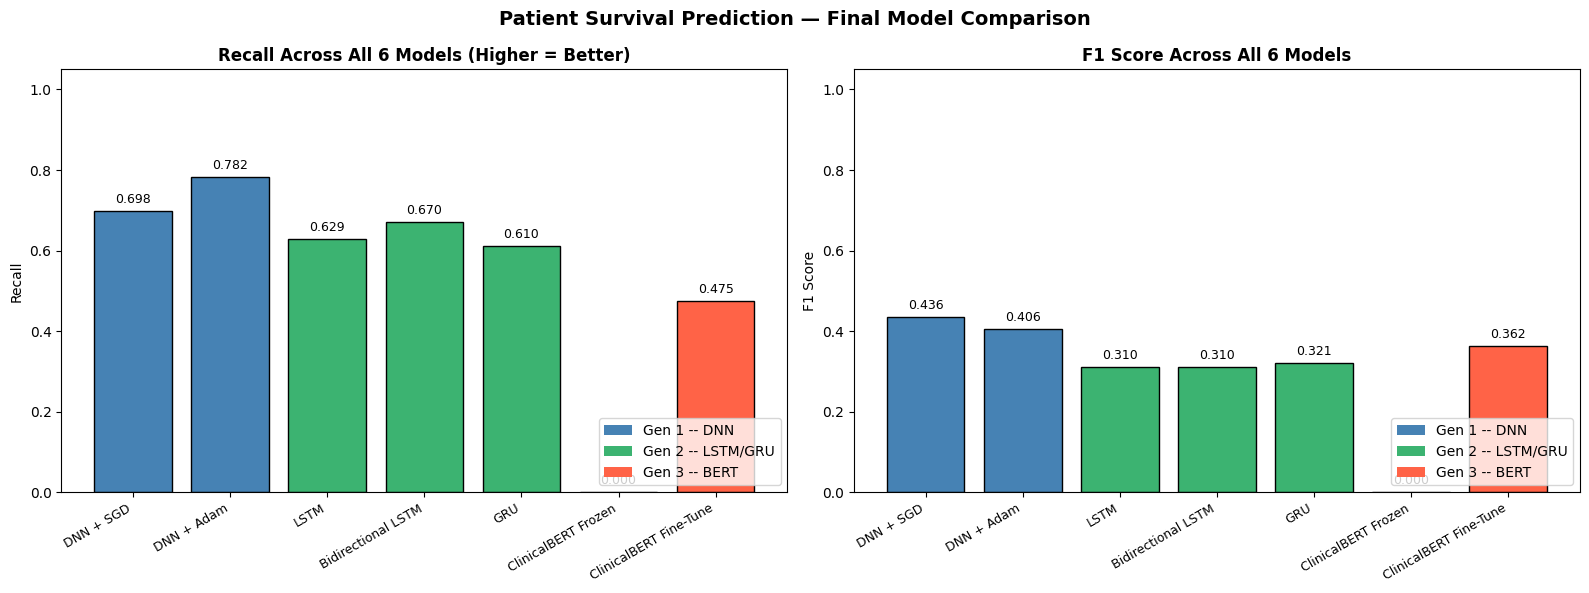

Saved: final_comparison_chart.png

ALL DONE — Notebook complete!


In [51]:
# ============================================================
# STEP 39: RECALL + F1 BAR CHART — ALL 6 MODELS
# WHY: Recall is the most critical metric in healthcare.
#      Missing deaths (FN) is far worse than false alarms.
# ============================================================
colors = (['steelblue'] * 2 + ['mediumseagreen'] * 3 + ['tomato'] * 2)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(final_table['Model'], final_table['Recall'], color=colors, edgecolor='black')
axes[0].set_title('Recall Across All 6 Models (Higher = Better)', fontweight='bold')
axes[0].set_ylabel('Recall'); axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(final_table['Model'], rotation=30, ha='right', fontsize=9)
for i, v in enumerate(final_table['Recall']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(final_table['Model'], final_table['F1 Score'], color=colors, edgecolor='black')
axes[1].set_title('F1 Score Across All 6 Models', fontweight='bold')
axes[1].set_ylabel('F1 Score'); axes[1].set_ylim(0, 1.05)
axes[1].set_xticklabels(final_table['Model'], rotation=30, ha='right', fontsize=9)
for i, v in enumerate(final_table['F1 Score']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',      label='Gen 1 -- DNN'),
    Patch(facecolor='mediumseagreen', label='Gen 2 -- LSTM/GRU'),
    Patch(facecolor='tomato',         label='Gen 3 -- BERT')
]
axes[0].legend(handles=legend_elements, loc='lower right')
axes[1].legend(handles=legend_elements, loc='lower right')

plt.suptitle('Patient Survival Prediction — Final Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison_chart.png', dpi=150)
plt.show()
print('Saved: final_comparison_chart.png')
print('\nALL DONE — Notebook complete!')